# Análisis de Datos — Trabajo Práctico Integrador

## Dataset: *Crímenes reportados en Chicago — 2025*

**Tema:** Policial · **Fuente:** [Chicago Data Portal — Crimes 2025](https://data.cityofchicago.org/Public-Safety/Crimes-2025/t7ek-mgzi/about_data)

En esta notebook analizamos y preparamos los datos para un problema de Machine Learning
supervisado. El objetivo es dejar el dataset listo para entrenar.

### El problema de ML que planteamos
- **Tipo:** clasificación binaria.
- **Variable target:** `Arrest`.
- **Motivación:** queremos predecir si un delito reportado terminará en arresto.

## Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from scipy.stats import chi2_contingency, pointbiserialr, entropy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import (SelectKBest, VarianceThreshold,
                                       mutual_info_classif, f_classif, chi2)
from sklearn.decomposition import PCA

from category_encoders import TargetEncoder

from imblearn.over_sampling import SMOTE

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### Funciones auxiliares

In [2]:
def shannon_entropy(series):
    p = series.value_counts(normalize=True)
    H = entropy(p, base=2)
    H_max = np.log2(len(p))
    return H, H_max


def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - (r - 1) ** 2 / (n - 1)
    kcorr = k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2corr / min(kcorr - 1, rcorr - 1))


def na_rate_by_group(data, group_col, flag_col, top=10):
    # % de faltante y cantidad de registros (n) por cada valor de otra variable
    g = data.groupby(group_col, observed=True)[flag_col]
    out = pd.DataFrame({"%_faltante": (g.mean() * 100).round(2), "n": g.size()})
    return out.sort_values("%_faltante", ascending=False).head(top)

## 1. Exploración y comprensión de los datos

### 1.1 Carga del dataset

In [3]:
df = pd.read_csv("../datasets/Crimes_-_2025_20260511.csv")
print(f"Observaciones (filas): {df.shape[0]:,}")
print(f"Variables (columnas):  {df.shape[1]}")
df.head()

Observaciones (filas): 237,193
Variables (columnas):  22


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,14075483,JK105557,12/31/2025 11:58:00 PM,050XX S PAULINA ST,0560,ASSAULT,SIMPLE,RESIDENCE,False,False,931,9,20.0,61.0,08A,1165860.0,1871343.0,2025,03/14/2026 03:41:39 PM,41.802549,-87.667246,POINT (-87.667246428 41.802549018)
1,14070833,JK100050,12/31/2025 11:55:00 PM,053XX W WASHINGTON BLVD,0930,MOTOR VEHICLE THEFT,THEFT / RECOVERY - AUTOMOBILE,APARTMENT,False,True,1522,15,37.0,25.0,07,1140809.0,1900235.0,2025,03/14/2026 03:41:39 PM,41.882329,-87.758411,POINT (-87.758411303 41.882328854)
2,14070799,JK100014,12/31/2025 11:54:00 PM,100XX W OHARE ST,2890,PUBLIC PEACE VIOLATION,OTHER VIOLATION,AIRCRAFT,False,False,1651,16,41.0,76.0,24,1100658.0,1934241.0,2025,03/14/2026 03:41:39 PM,41.976290,-87.905227,POINT (-87.905227221 41.976290414)
3,14070745,JK100011,12/31/2025 11:54:00 PM,100XX W OHARE ST,2890,PUBLIC PEACE VIOLATION,OTHER VIOLATION,AIRCRAFT,False,False,1651,16,41.0,76.0,24,1100658.0,1934241.0,2025,03/14/2026 03:41:39 PM,41.976290,-87.905227,POINT (-87.905227221 41.976290414)
4,14070845,JK100006,12/31/2025 11:54:00 PM,013XX W LAKE ST,0454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",RESTAURANT,True,False,1215,12,27.0,28.0,08B,1167120.0,1901555.0,2025,03/14/2026 03:41:39 PM,41.885427,-87.661759,POINT (-87.661759042 41.885426714)


### 1.2 Descripción del dataset

Los datos vienen del sistema CLEAR del Departamento de Policía de Chicago. Cada fila es **un
delito reportado** durante 2025 (salvo en homicidios, donde hay **una fila por víctima**). Por
privacidad, las direcciones se muestran **a nivel de cuadra**, no en la ubicación exacta.

| Variable | Descripción | Tipo |
|---|---|---|
| `ID` | Identificador único del registro | Identificador |
| `Case Number` | Número de caso, único por incidente | Identificador |
| `Date` | Fecha y hora del incidente | Fecha/hora |
| `Block` | Dirección a nivel de cuadra | Categórica |
| `IUCR` | Código Illinois UCR | Categórica |
| `Primary Type` | Tipo de delito | Categórica |
| `Description` | Subcategoría del tipo de delito | Categórica |
| `Location Description` | Tipo de lugar (calle, vivienda, etc.) | Categórica |
| `Arrest` | ¿Hubo arresto? | Booleana (target) |
| `Domestic` | ¿Incidente doméstico? | Booleana |
| `Beat` | Unidad geográfica policial más chica | Categórica |
| `District` | Distrito policial | Categórica |
| `Ward` | Distrito del Concejo Municipal | Categórica |
| `Community Area` | Área comunitaria | Categórica |
| `FBI Code` | Clasificación del delito | Categórica |
| `X Coordinate` | Coordenada X | Numérica |
| `Y Coordinate` | Coordenada Y | Numérica |
| `Year` | Año del incidente | Numérica |
| `Updated On` | Fecha de última actualización | Fecha/hora |
| `Latitude` | Latitud | Numérica |
| `Longitude` | Longitud | Numérica |
| `Location` | Punto (latitud, longitud) | Geográfica |

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237193 entries, 0 to 237192
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    237193 non-null  int64  
 1   Case Number           237193 non-null  object 
 2   Date                  237193 non-null  object 
 3   Block                 237193 non-null  object 
 4   IUCR                  237193 non-null  object 
 5   Primary Type          237193 non-null  object 
 6   Description           237193 non-null  object 
 7   Location Description  236050 non-null  object 
 8   Arrest                237193 non-null  bool   
 9   Domestic              237193 non-null  bool   
 10  Beat                  237193 non-null  int64  
 11  District              237193 non-null  int64  
 12  Ward                  237192 non-null  float64
 13  Community Area        237184 non-null  float64
 14  FBI Code              237193 non-null  object 
 15  

### 1.3 Identificación y ajuste de los tipos de variables

Corregimos el tipo de dos grupos de variables:

- `Date` y `Updated On` son **fechas**.
- `Beat`, `District`, `Ward` y `Community Area` son **códigos administrativos**.

In [5]:
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %I:%M:%S %p")
df["Updated On"] = pd.to_datetime(df["Updated On"], format="%m/%d/%Y %I:%M:%S %p")

for col in ["Beat", "District", "Ward", "Community Area"]:
    df[col] = df[col].astype("Int64").astype("category")

df.dtypes

ID                               int64
Case Number                     object
Date                    datetime64[ns]
Block                           object
IUCR                            object
Primary Type                    object
Description                     object
Location Description            object
Arrest                            bool
Domestic                          bool
Beat                          category
District                      category
Ward                          category
Community Area                category
FBI Code                        object
X Coordinate                   float64
Y Coordinate                   float64
Year                             int64
Updated On              datetime64[ns]
Latitude                       float64
Longitude                      float64
Location                        object
dtype: object

### 1.4 Cardinalidad y diversidad

In [6]:
cardinality = df.nunique().sort_values(ascending=False).to_frame("valores_unicos")
cardinality["%_unicos"] = (cardinality["valores_unicos"] / len(df) * 100).round(2)
cardinality

,valores_unicos,%_unicos
ID,237193,100.00
Case Number,237172,99.99
Date,122740,51.75
Location,113352,47.79
Longitude,113324,47.78
Latitude,113323,47.78
Y Coordinate,67552,28.48
X Coordinate,48938,20.63
Block,28318,11.94
Updated On,536,0.23


Observamos una **alta cardinalidad** en `Block`, `Description`, `IUCR`, `Beat` y `Location Description`.

Calculamos la **moda** de cada categórica y su proporción.

In [7]:
cat_cols = ["Block", "IUCR", "Description", "Location Description", "Beat",
            "Community Area", "Ward", "Primary Type", "FBI Code", "District"]

rows = []
for col in cat_cols:
    prop = df[col].value_counts(normalize=True)
    rows.append({"variable": col, "moda": prop.index[0],
                 "%_moda": round(prop.iloc[0] * 100, 2)})

modes = (pd.DataFrame(rows).set_index("variable")
         .sort_values("%_moda", ascending=False).rename_axis(None))
modes

,moda,%_moda
Location Description,STREET,26.39
FBI Code,06,24.73
Primary Type,THEFT,23.24
Description,SIMPLE,12.66
IUCR,0486,7.92
District,8,6.42
Community Area,25,4.97
Ward,27,4.79
Beat,1834,1.26
Block,001XX N STATE ST,0.24


Lo complementamos con la **entropía de Shannon**, que mira toda la distribución y no solo la
categoría más frecuente; la ordenamos por la entropía normalizada `H/H_max` (qué fracción de
la diversidad máxima alcanza cada una).

In [8]:
rows = []
for col in cat_cols:
    H, H_max = shannon_entropy(df[col])
    rows.append({"variable": col, "H": H, "H_max": H_max, "H_norm": H / H_max})

entropies = (pd.DataFrame(rows).set_index("variable")
             .sort_values("H_norm", ascending=False).round(2).rename_axis(None))
entropies

,H,H_max,H_norm
Beat,7.99,8.10,0.99
District,4.41,4.52,0.97
Ward,5.47,5.64,0.97
Community Area,5.86,6.27,0.94
Block,13.80,14.79,0.93
FBI Code,3.48,4.70,0.74
Primary Type,3.42,4.95,0.69
IUCR,5.60,8.40,0.67
Description,5.41,8.30,0.65
Location Description,3.95,7.02,0.56


> Las variables **geográficas** tienen entropía muy alta: están casi uniformes, esto sugiere
> que el delito se reparte por toda la ciudad y ninguna zona concentra los casos. El **tipo de
> delito** y el **tipo de lugar** (calle, vivienda, etc.) tienen entropía más baja: muchas
> categorías pero concentradas en unas pocas.

## 2. Patrones generales y distribuciones

### 2.1 La variable target: `Arrest`

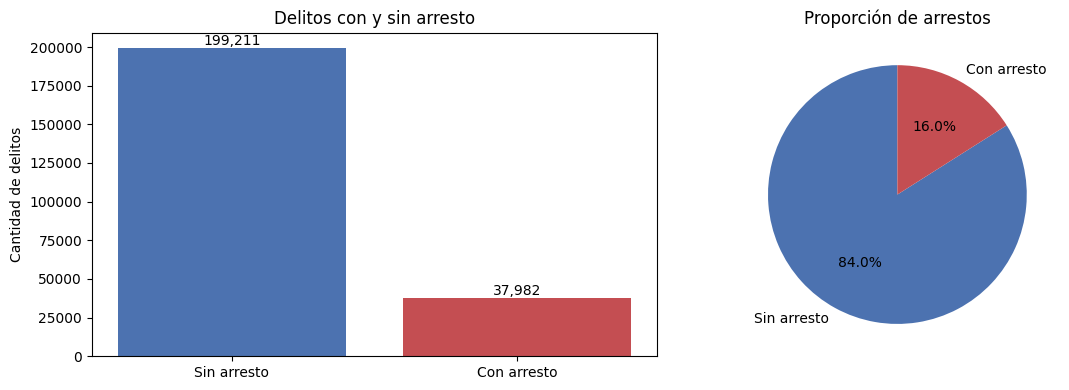

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
arrest_counts = df["Arrest"].value_counts()
axes[0].bar(["Sin arresto", "Con arresto"], arrest_counts.values,
            color=["#4C72B0", "#C44E52"])
axes[0].set_title("Delitos con y sin arresto")
axes[0].set_ylabel("Cantidad de delitos")
for i, v in enumerate(arrest_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

prop = df["Arrest"].value_counts(normalize=True) * 100
axes[1].pie(prop.values, labels=["Sin arresto", "Con arresto"], autopct="%1.1f%%",
            colors=["#4C72B0", "#C44E52"], startangle=90)
axes[1].set_title("Proporción de arrestos")
plt.tight_layout(); plt.show()

> Solo el **~16 %** de los delitos terminan en arresto. El target está
> **desbalanceado** ~5:1.

### 2.2 Variables categóricas: tipos de delito y lugares

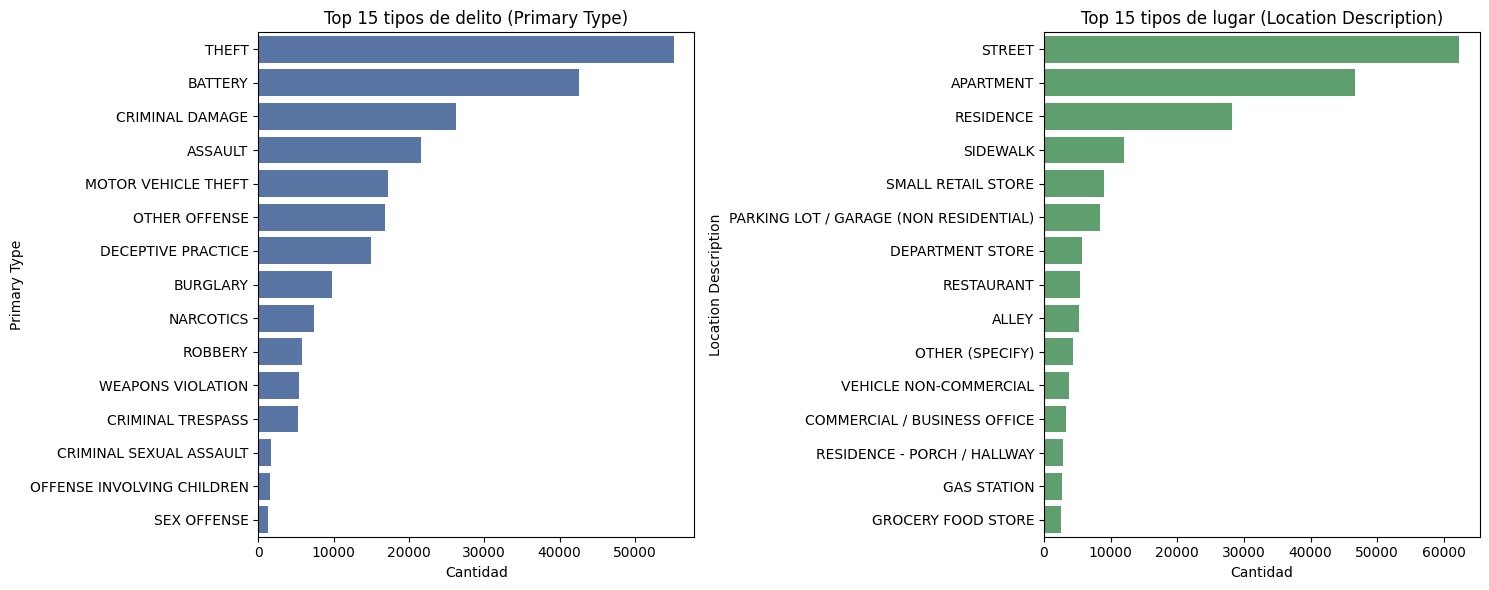

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
top_types = df["Primary Type"].value_counts().head(15)
sns.barplot(y=top_types.index, x=top_types.values, ax=axes[0], color="#4C72B0")
axes[0].set_title("Top 15 tipos de delito (Primary Type)")
axes[0].set_xlabel("Cantidad")

top_loc = df["Location Description"].value_counts().head(15)
sns.barplot(y=top_loc.index, x=top_loc.values, ax=axes[1], color="#55A868")
axes[1].set_title("Top 15 tipos de lugar (Location Description)")
axes[1].set_xlabel("Cantidad")
plt.tight_layout(); plt.show()

> La mayoría de los delitos son `THEFT`, `BATTERY` y `CRIMINAL DAMAGE`, y
> pasan sobre todo en la calle (`STREET`), en viviendas (`RESIDENCE`, `APARTMENT`) y en la
> vereda (`SIDEWALK`).

`Description` es una **subcategoría** de `Primary Type`: cada tipo de delito se subdivide en
descripciones más específicas. Para verlo, tomamos los tipos más frecuentes y mostramos en qué
`Description` se parten.

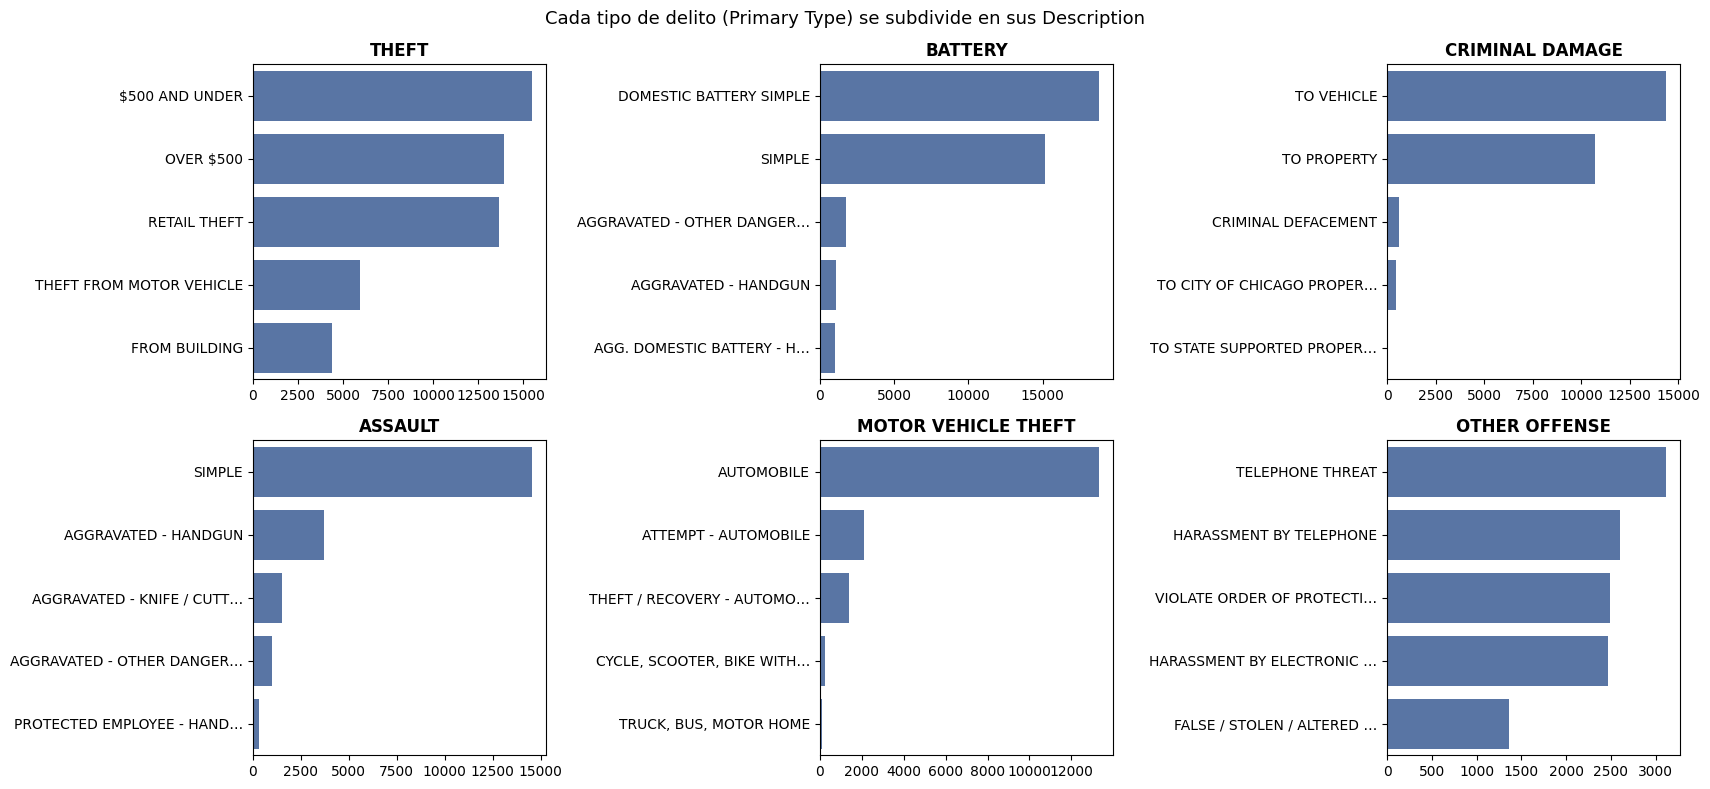

In [11]:
def corto(s, n=26):
    return s if len(s) <= n else s[:n - 1] + "…"

top_pt = df["Primary Type"].value_counts().head(6).index
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, pt in zip(axes.flat, top_pt):
    sub = df[df["Primary Type"] == pt]["Description"].value_counts().head(5)
    sns.barplot(y=[corto(s) for s in sub.index.astype(str)], x=sub.values, ax=ax, color="#4C72B0")
    ax.set_title(pt, fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("")
fig.suptitle("Cada tipo de delito (Primary Type) se subdivide en sus Description", fontsize=13)
plt.tight_layout(); plt.show()

`FBI Code` e `IUCR` son otras formas de tipificar los delitos.

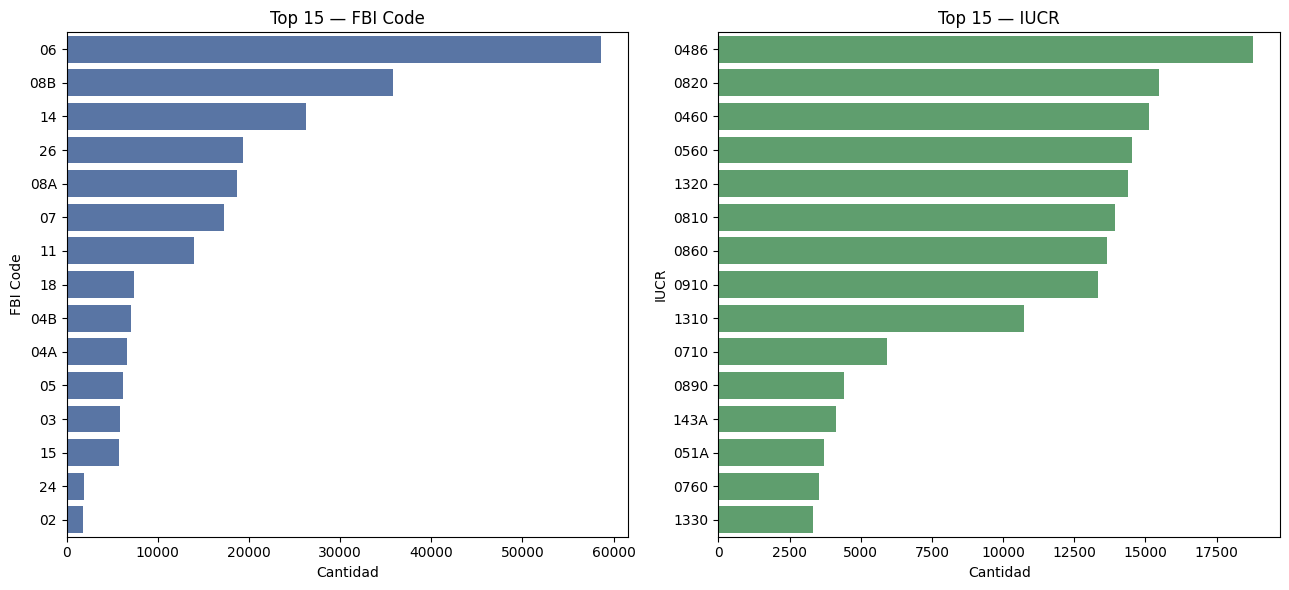

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, col, color in zip(axes, ["FBI Code", "IUCR"], ["#4C72B0", "#55A868"]):
    top = df[col].value_counts().head(15)
    sns.barplot(y=top.index.astype(str), x=top.values, ax=ax, color=color)
    ax.set_title(f"Top 15 — {col}")
    ax.set_xlabel("Cantidad")
plt.tight_layout(); plt.show()

### 2.3 Patrones temporales

Sacamos las componentes de la fecha para ver estacionalidad y ciclos. Para la serie en el
tiempo usamos un **gráfico de línea**, y para el ciclo por hora y día de la semana, **barras**
y un **heatmap**.

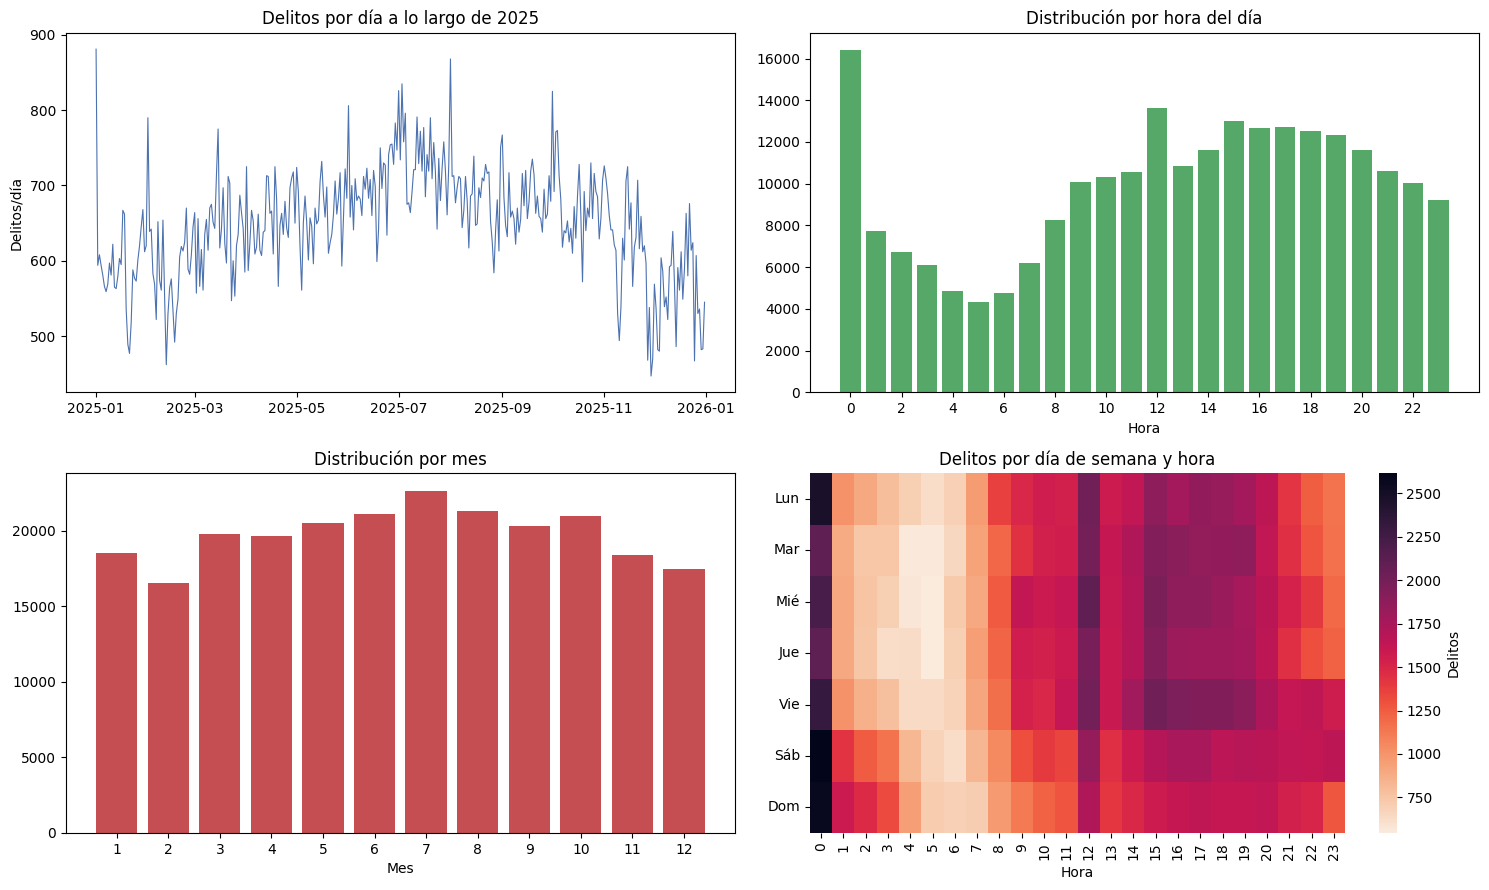

In [13]:
df["Hour"] = df["Date"].dt.hour
df["Weekday"] = df["Date"].dt.dayofweek          # 0 = lunes
df["Month"] = df["Date"].dt.month
df["DayOfMonth"] = df["Date"].dt.day

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# Serie diaria
daily_counts = df.set_index("Date").resample("D").size()
axes[0, 0].plot(daily_counts.index, daily_counts.values, color="#4C72B0", lw=0.8)
axes[0, 0].set_title("Delitos por día a lo largo de 2025")
axes[0, 0].set_ylabel("Delitos/día")

# Por hora del día
by_hour = df["Hour"].value_counts().sort_index()
axes[0, 1].bar(by_hour.index, by_hour.values, color="#55A868")
axes[0, 1].set_title("Distribución por hora del día")
axes[0, 1].set_xlabel("Hora"); axes[0, 1].set_xticks(range(0, 24, 2))

# Por mes
by_month = df["Month"].value_counts().sort_index()
axes[1, 0].bar(by_month.index, by_month.values, color="#C44E52")
axes[1, 0].set_title("Distribución por mes")
axes[1, 0].set_xlabel("Mes"); axes[1, 0].set_xticks(range(1, 13))

# Heatmap día de semana x hora
days = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
pivot = df.pivot_table(index="Weekday", columns="Hour", values="ID", aggfunc="count")
sns.heatmap(pivot, cmap="rocket_r", ax=axes[1, 1], cbar_kws={"label": "Delitos"})
axes[1, 1].set_yticklabels(days, rotation=0)
axes[1, 1].set_title("Delitos por día de semana y hora")
axes[1, 1].set_xlabel("Hora"); axes[1, 1].set_ylabel("")
plt.tight_layout(); plt.show()

> Aparecen **picos raros a la medianoche (00:00) y al mediodía (12:00)**, y otro el **día 1 de
> cada mes**. Pareciera que cuando no se sabe la hora exacta se carga una hora "redonda"
> (`00:00` o `12:00`) y el día 1. O sea, es un **sesgo de registro** que tenemos que tener
> presente. Sacando eso, los delitos suben a la tarde-noche y en los meses cálidos (verano del
> hemisferio norte).

### 2.4 Distribución geográfica

Ponemos cada delito como un punto según su longitud y latitud y lo coloreamos por arresto;
con eso prácticamente reconstruimos el mapa de Chicago. Aclaramos que las ubicaciones son
**aproximadas** (a nivel de cuadra), no exactas.

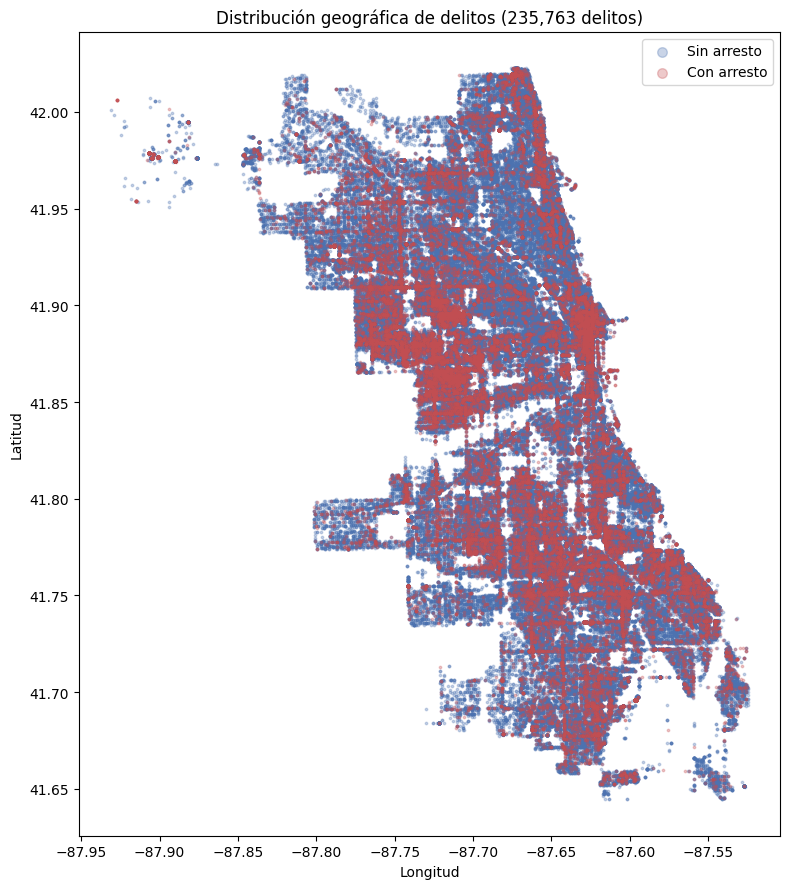

In [14]:
geo = df.dropna(subset=["Latitude", "Longitude"])
fig, ax = plt.subplots(figsize=(8, 9))
for val, color, label in [(False, "#4C72B0", "Sin arresto"), (True, "#C44E52", "Con arresto")]:
    sub = geo[geo["Arrest"] == val]
    ax.scatter(sub["Longitude"], sub["Latitude"], s=3, alpha=0.3, c=color, label=label)
ax.set_title(f"Distribución geográfica de delitos ({len(geo):,} delitos)")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.legend(markerscale=4)
plt.tight_layout(); plt.show()

Ahora coloreamos el mismo mapa por las **divisiones administrativas geográficas** (`District`,
`Ward`, `Community Area`, `Beat`) en vez del arresto. Cada una parte la ciudad en un mosaico de
**regiones contiguas**, de más grueso a más fino: son, en el fondo, **geografía discretizada**.

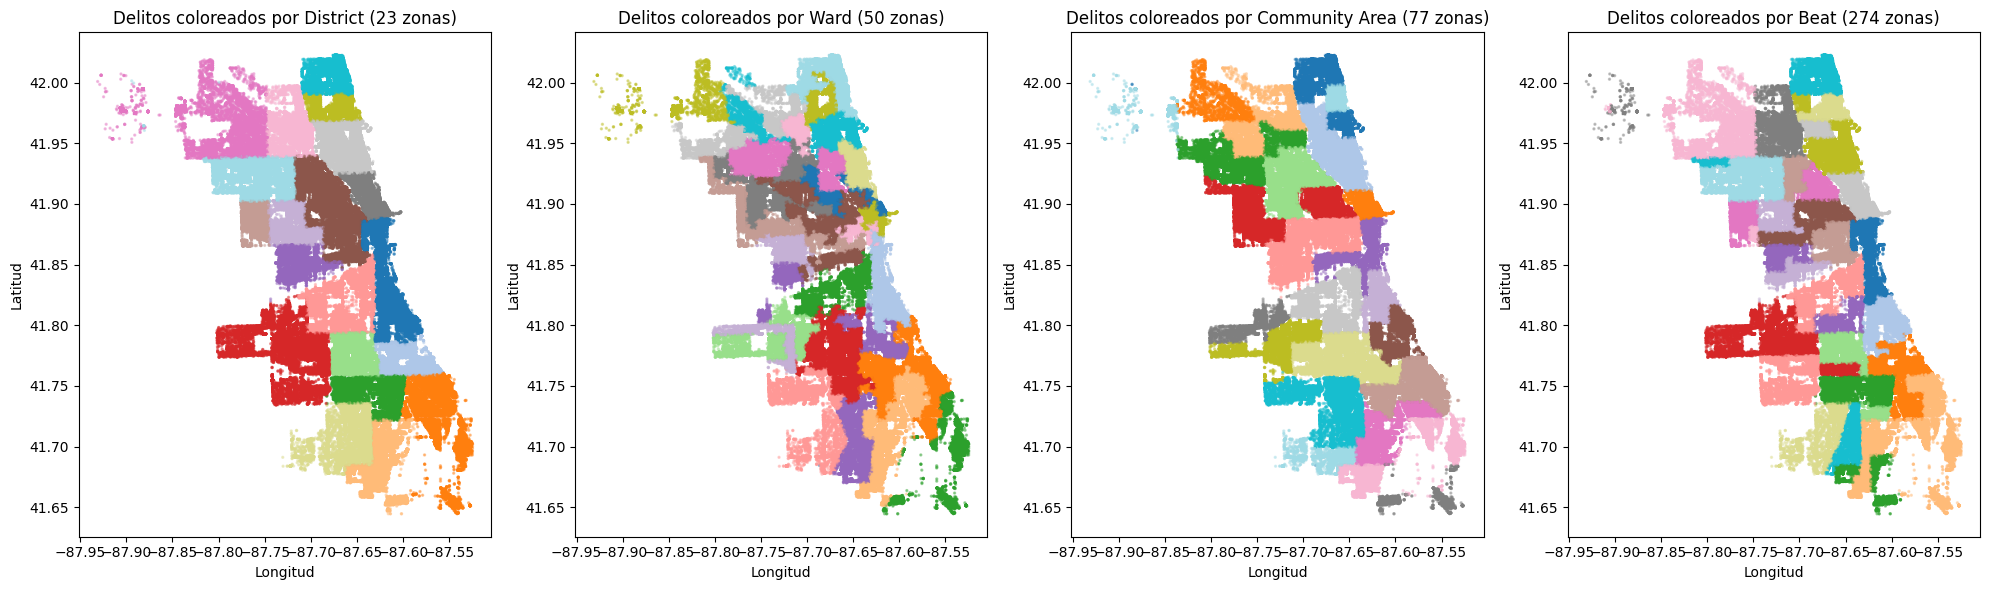

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
for ax, col in zip(axes, ["District", "Ward", "Community Area", "Beat"]):
    codes = geo[col].astype("category").cat.codes
    ax.scatter(geo["Longitude"], geo["Latitude"], c=codes, s=2, alpha=0.4, cmap="tab20")
    ax.set_title(f"Delitos coloreados por {col} ({geo[col].nunique()} zonas)")
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
plt.tight_layout(); plt.show()

> Las cuatro reconstruyen el mapa como un mosaico de zonas: estas categóricas **codifican
> ubicación**. Por eso están asociadas entre sí y con las
> coordenadas. Dejamos afuera `Block`: es la geográfica más fina (~28k cuadras) y, al estar
> geocodificada a nivel de cuadra, es prácticamente equivalente al propio punto del mapa, así
> que colorear por ella no agruparía nada.

### 2.5 Tasa de arresto por tipo de delito y hora

Miramos la **tasa de arresto** según el **tipo de delito** y la **hora** para ver cuánto aporta cada variable.

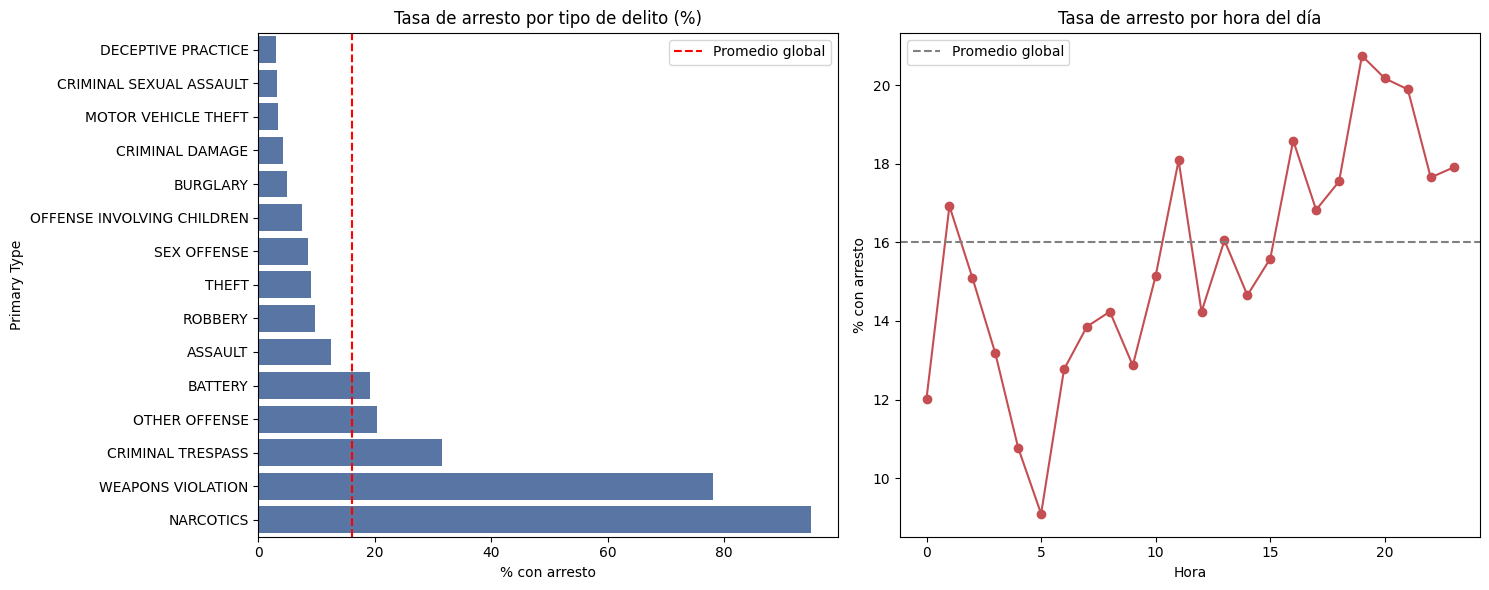

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Tasa de arresto por tipo de delito (top por volumen)
top_types = df["Primary Type"].value_counts().head(15).index
rate_by_type = df[df["Primary Type"].isin(top_types)].groupby("Primary Type")["Arrest"].mean().sort_values()
sns.barplot(y=rate_by_type.index, x=rate_by_type.values * 100, ax=axes[0], color="#4C72B0")
axes[0].set_title("Tasa de arresto por tipo de delito (%)")
axes[0].set_xlabel("% con arresto")
axes[0].axvline(df["Arrest"].mean() * 100, color="red", ls="--", label="Promedio global")
axes[0].legend()

# Tasa de arresto por hora
rate_by_hour = df.groupby("Hour")["Arrest"].mean() * 100
axes[1].plot(rate_by_hour.index, rate_by_hour.values, marker="o", color="#C44E52")
axes[1].axhline(df["Arrest"].mean() * 100, color="gray", ls="--", label="Promedio global")
axes[1].set_title("Tasa de arresto por hora del día")
axes[1].set_xlabel("Hora"); axes[1].set_ylabel("% con arresto"); axes[1].legend()
plt.tight_layout(); plt.show()

> Se ve que el **tipo de delito** predice muchísimo el arresto.
> En delitos como `NARCOTICS` (~95 %), `WEAPONS VIOLATION`, `PROSTITUTION` o
> `LIQUOR LAW VIOLATION`, la tasa es altísima, mientras que en `THEFT`, `BURGLARY` o
> `CRIMINAL DAMAGE` es muy baja. La **hora** también mueve la tasa, aunque mucho menos: cae de
> madrugada (~9 % a las 5) y sube hacia la tarde-noche (~20 % cerca de las 19–21 h).

### 2.6 Incidentes domésticos vs. arresto

Cruzamos `Domestic` con el target en una **tabla de contingencia normalizada por fila** y
calculamos el **coeficiente phi**, para ver si la tasa de arresto cambia según el incidente sea
doméstico o no.

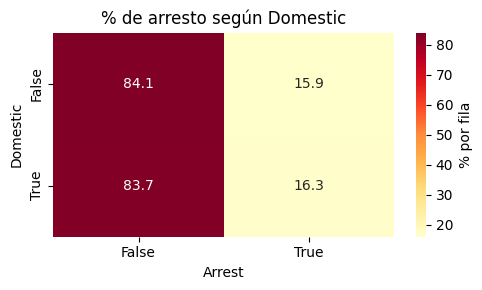

Coeficiente phi (Domestic vs Arrest): 0.0037


Arrest,False,True
Domestic,,
False,84.1,15.9
True,83.7,16.3


In [17]:
# Tabla de contingencia normalizada por filas: Domestic vs Arrest
ct = pd.crosstab(df["Domestic"], df["Arrest"], normalize="index") * 100
plt.figure(figsize=(5, 3))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "% por fila"})
plt.title("% de arresto según Domestic")
plt.tight_layout(); plt.show()

# Coeficiente phi: correlación entre dos variables binarias (Domestic y Arrest)
phi = np.corrcoef(df["Domestic"].astype(int), df["Arrest"].astype(int))[0, 1]
print(f"Coeficiente phi (Domestic vs Arrest): {phi:.4f}")
ct.round(1)

> La tasa de arresto es prácticamente la misma sea o no doméstico (~16 %), y el **coeficiente
> phi ≈ 0** confirma que no hay relación entre las variables.

### 2.7 Medidas de asociación

Calculamos **Cramér's V** para medir la relación de las variables categóricas con el target.

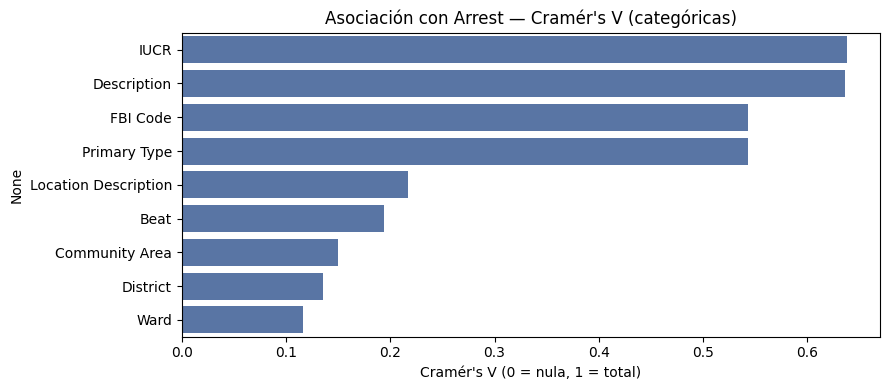

IUCR                    0.638
Description             0.636
FBI Code                0.543
Primary Type            0.543
Location Description    0.217
Beat                    0.194
Community Area          0.150
District                0.136
Ward                    0.116
dtype: float64

In [18]:
cat_features = ["Primary Type", "FBI Code", "IUCR", "Description", "Location Description",
                "District", "Ward", "Community Area", "Beat"]
association = {c: cramers_v(df[c], df["Arrest"]) for c in cat_features}
association = pd.Series(association).sort_values(ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(x=association.values, y=association.index, color="#4C72B0")
plt.title("Asociación con Arrest — Cramér's V (categóricas)")
plt.xlabel("Cramér's V (0 = nula, 1 = total)")
plt.tight_layout(); plt.show()
association.round(3)

> Las variables de **tipo de delito** (`IUCR`, `Description`, `FBI Code`, `Primary Type`) son,
> de lejos, las más asociadas al arresto; el tipo de lugar y las geográficas quedan muy por
> debajo. Las más finas (`IUCR`/`Description`) puntúan algo más alto, en parte por su mayor
> cardinalidad.

Calculamos el **punto-biserial** para ver si hay correlación entre las variables numéricas y el
target. Algunas de esas numéricas las derivamos de la fecha, como la **hora**, el **día de la
semana** o el **mes**.

In [19]:
num_features = ["Hour", "Weekday", "Month", "Latitude", "Longitude"]
pb = {}
for c in num_features:
    sub = df[[c, "Arrest"]].dropna()
    r, p = pointbiserialr(sub["Arrest"].astype(int), sub[c])
    pb[c] = r
pd.Series(pb).sort_values(key=abs, ascending=False).round(3).to_frame("punto-biserial")

,punto-biserial
Hour,0.058
Longitude,-0.053
Month,-0.030
Latitude,0.006
Weekday,0.003


> Las numéricas casi no se asocian de forma **lineal** con el target (punto-biserial cercano a
> 0; la más alta es la hora, ~0.06). Igual algo aportan de forma no lineal, como vimos con la
> tasa por hora en §2.5.

Armamos la **matriz de asociación feature×feature** (Cramér's V) para encontrar
**redundancias** entre las categóricas.

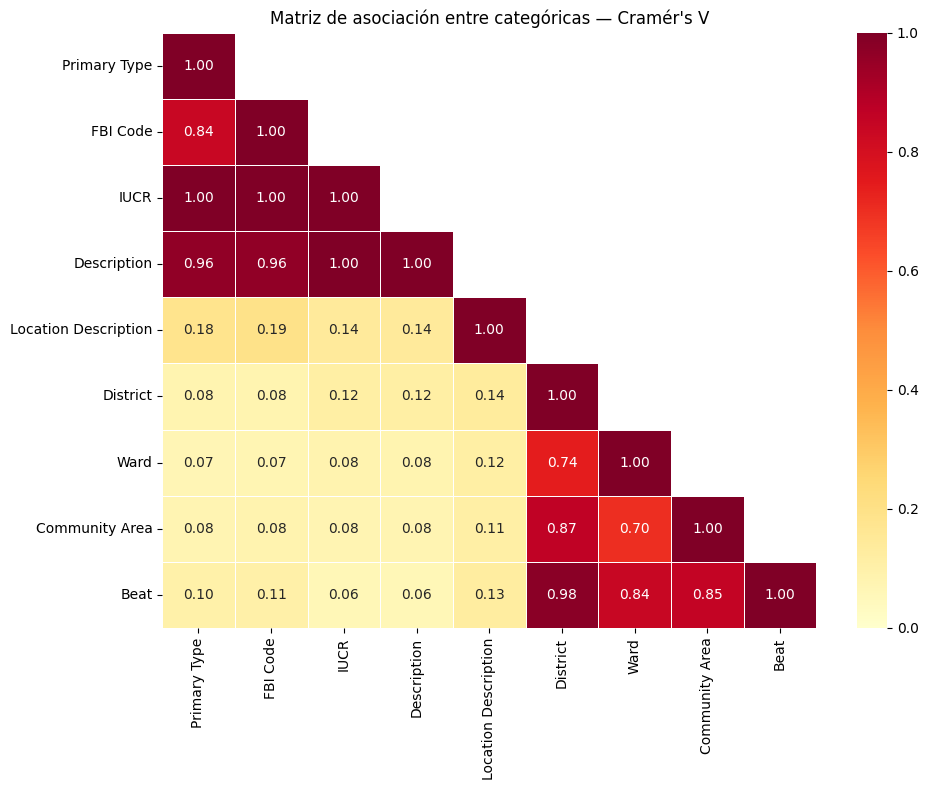

In [20]:
cats_matrix = cat_features
n = len(cats_matrix)
v_mat = pd.DataFrame(np.eye(n), index=cats_matrix, columns=cats_matrix)
for i in range(n):
    for j in range(i + 1, n):
        v = cramers_v(df[cats_matrix[i]], df[cats_matrix[j]])
        v_mat.iloc[i, j] = v_mat.iloc[j, i] = v

mask = np.triu(np.ones_like(v_mat, dtype=bool), k=1)
plt.figure(figsize=(10, 8))
sns.heatmap(v_mat, mask=mask, annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5)
plt.title("Matriz de asociación entre categóricas — Cramér's V")
plt.tight_layout(); plt.show()

> Aparecen dos bloques **redundantes**: el de **tipo de delito** (`IUCR`/`Description`/
> `Primary Type`/`FBI Code`, con Cramér's V ~0.8–1.0 entre sí) y el **geográfico**
> (`District`/`Ward`/`Community Area`/`Beat`, ~0.7–0.98). Dentro de cada bloque las variables
> dicen casi lo mismo.

Para las pocas **numéricas** que tenemos miramos la correlación de **Pearson** (lineal) y
**Spearman** (monótona), con máscara triangular.

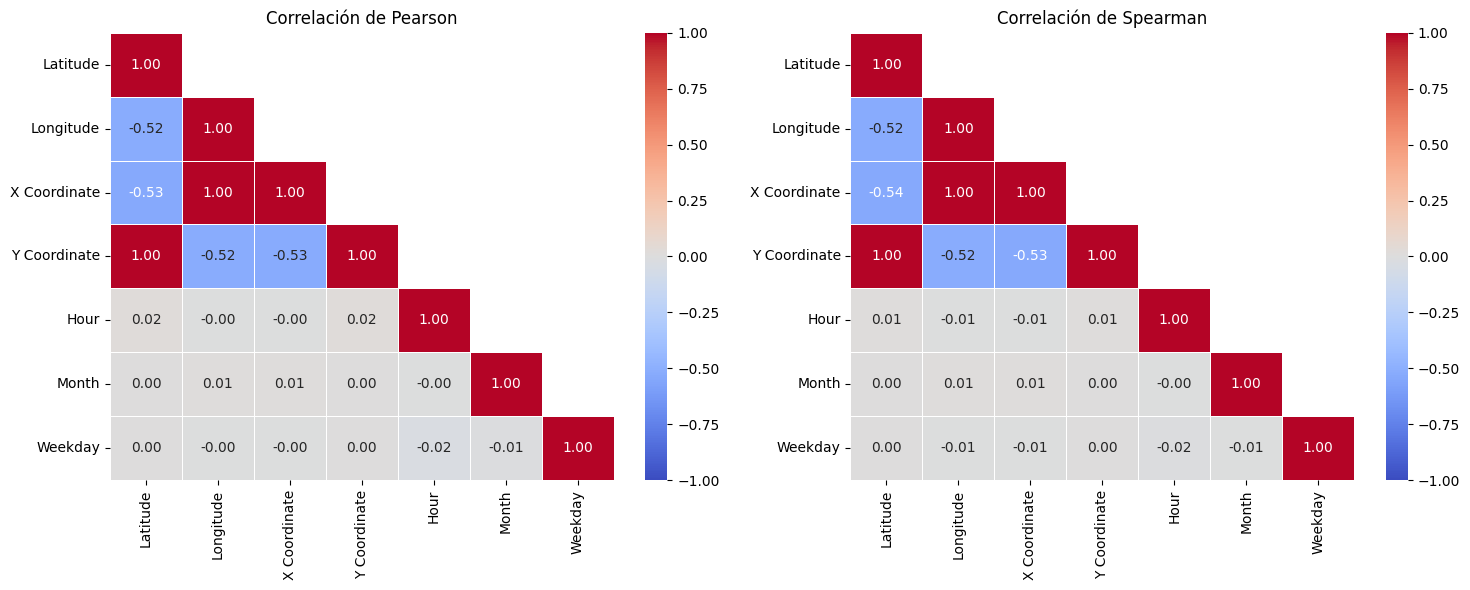

In [21]:
num_corr = ["Latitude", "Longitude", "X Coordinate", "Y Coordinate", "Hour", "Month", "Weekday"]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, method in zip(axes, ["pearson", "spearman"]):
    corr = df[num_corr].corr(method=method)
    m = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=m, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                vmin=-1, vmax=1, linewidths=0.5, ax=ax)
    ax.set_title(f"Correlación de {method.capitalize()}")
plt.tight_layout(); plt.show()

> Como es esperable `Latitude`/`Longitude` están perfectamente correlacionadas con `X`/`Y Coordinate`
> (Pearson ≈ 1): son lo mismo repetido. Entre
> el resto de las numéricas casi no hay correlación lineal.

## 3. Detección de outliers

Las **únicas variables numéricas** que tenemos son las **coordenadas** (`Latitude`,
`Longitude`); el resto son categóricas (códigos administrativos) o temporales cíclicas, que
no admiten outliers en el sentido clásico.

Y como vimos en el **mapa de la sección 2.4**, todos los puntos caen dentro de Chicago: no hay
coordenadas raras ni errores geográficos. Por eso **acá no tiene sentido buscar outliers con
métodos estadísticos** (IQR, 3σ): sobre coordenadas solo marcarían los bordes de la ciudad,
que son ubicaciones perfectamente válidas.

> Lo único que sí tenemos que tener presente es el **sesgo temporal del 00:00 / 12:00 / día 1**
> (§2.3); lo dejamos documentado pero no lo corregimos porque no podemos recuperar el valor
> real.

## 4. Análisis de datos faltantes

### 4.1 Recuento de faltantes

In [22]:
nulls = df.isna().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
null_table = pd.DataFrame({"faltantes": nulls, "%": (nulls / len(df) * 100).round(3)})
null_table

,faltantes,%
X Coordinate,1430,0.603
Y Coordinate,1430,0.603
Latitude,1430,0.603
Longitude,1430,0.603
Location,1430,0.603
Location Description,1143,0.482
Community Area,9,0.004
Ward,1,0.000


Miramos el patrón de faltantes con **missingno**: `matrix` (fila a fila) y `heatmap`
(correlación de nulidad entre variables), para ver si faltan juntas en bloque.

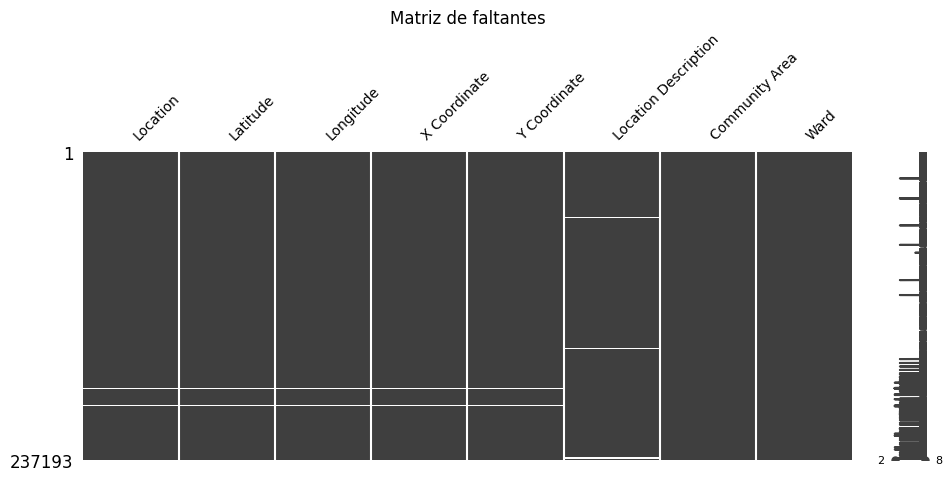

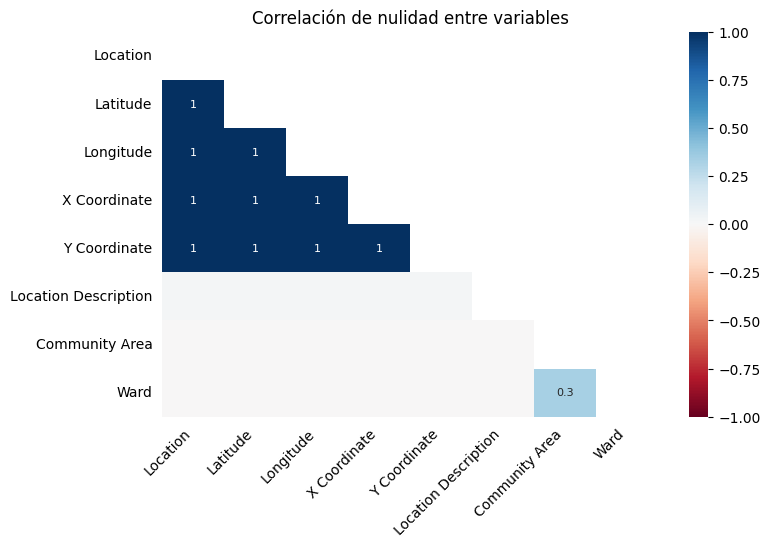

In [23]:
cols_with_na = ["Location", "Latitude", "Longitude", "X Coordinate", "Y Coordinate",
                "Location Description", "Community Area", "Ward"]

msno.matrix(df[cols_with_na], figsize=(11, 4), fontsize=10)
plt.title("Matriz de faltantes")
plt.show()

msno.heatmap(df[cols_with_na], figsize=(8, 5), fontsize=10)
plt.title("Correlación de nulidad entre variables")
plt.show()

> Falta muy poco y en pocas columnas. Las **geográficas** (`X`/`Y Coordinate`, `Latitude`,
> `Longitude`, `Location`) faltan **siempre juntas**, como
> muestra la nulidad correlacionada ≈ 1 en el heatmap. `Location Description` tiene un faltante
> propio y chico, y `Community Area` y `Ward` son casos aislados. En la
> próxima sección vemos **por qué** faltan.

### 4.2 Análisis del mecanismo de los faltantes

Para saber el mecanismo, miramos el %
de faltante por "tajadas" de otras variables.

In [24]:
df["geo_faltante"] = df["Latitude"].isna()

print("Tasa de faltante geográfico por tipo de delito (top):")
print(na_rate_by_group(df, "Primary Type", flag_col="geo_faltante"))

Tasa de faltante geográfico por tipo de delito (top):
                         %_faltante      n
Primary Type                              
OBSCENITY                      1.82     55
SEX OFFENSE                    1.50   1329
INTIMIDATION                   1.39    144
DECEPTIVE PRACTICE             1.24  15023
ARSON                          1.07    374
PUBLIC PEACE VIOLATION         1.04   1056
CRIMINAL SEXUAL ASSAULT        0.96   1672
STALKING                       0.87    576
CRIMINAL TRESPASS              0.79   5321
OTHER OFFENSE                  0.70  16800


In [25]:
print("Tasa de faltante geográfico por tipo de lugar (top):")
print(na_rate_by_group(df, "Location Description", flag_col="geo_faltante"))

Tasa de faltante geográfico por tipo de lugar (top):
                                                %_faltante    n
Location Description                                           
FIRE STATION                                          6.67   30
COIN OPERATED MACHINE                                 5.88   17
COLLEGE / UNIVERSITY - RESIDENCE HALL                 5.88   17
MOVIE HOUSE / THEATER                                 2.63   76
LIBRARY                                               1.74  402
FEDERAL BUILDING                                      1.72   58
OTHER RAILROAD PROPERTY / TRAIN DEPOT                 1.60  187
BARBERSHOP                                            1.47  136
AIRPORT TERMINAL LOWER LEVEL - NON-SECURE AREA        1.46  137
COLLEGE / UNIVERSITY - GROUNDS                        1.32   76


In [26]:
print("Tasa de faltante geográfico por Arrest:")
print(na_rate_by_group(df, "Arrest", flag_col="geo_faltante"))

Tasa de faltante geográfico por Arrest:
        %_faltante       n
Arrest                    
False         0.61  199211
True          0.55   37982


Aunque no tengamos las coordenadas, las divisiones geográficas categóricas (`District`,
`Community Area`) sí están presentes en esas filas, así que también miramos si el faltante se
concentra en alguna **zona** de la ciudad.

In [27]:
print("Tasa de faltante geográfico por distrito policial (top):")
print(na_rate_by_group(df, "District", flag_col="geo_faltante"))

Tasa de faltante geográfico por distrito policial (top):
          %_faltante      n
District                   
14              0.76   8035
16              0.73   8103
20              0.70   5001
22              0.69   7629
17              0.67   7302
8               0.66  15236
1               0.65  13698
3               0.63  12738
24              0.63   7617
6               0.63  13591


In [28]:
print("Tasa de faltante geográfico por área comunitaria (top):")
print(na_rate_by_group(df, "Community Area", flag_col="geo_faltante"))

Tasa de faltante geográfico por área comunitaria (top):
                %_faltante     n
Community Area                  
72                    1.32   984
57                    1.09  1099
9                     1.08   277
45                    1.05  1051
65                    1.04  1732
64                    0.96  1047
22                    0.91  4515
55                    0.91   769
17                    0.85  1420
20                    0.85  1180


Repetimos el análisis para el faltante de **`Location Description`**: vemos si depende del tipo
de delito.

In [29]:
df["loc_faltante"] = df["Location Description"].isna()
print("Faltante de Location Description por tipo de delito (top):")
print(na_rate_by_group(df, "Primary Type", flag_col="loc_faltante"))

Faltante de Location Description por tipo de delito (top):
                        %_faltante      n
Primary Type                             
DECEPTIVE PRACTICE            7.59  15023
ARSON                         0.00    374
MOTOR VEHICLE THEFT           0.00  17243
THEFT                         0.00  55131
STALKING                      0.00    576
SEX OFFENSE                   0.00   1329
ROBBERY                       0.00   5811
PUBLIC PEACE VIOLATION        0.00   1056
PUBLIC INDECENCY              0.00     10
PROSTITUTION                  0.00    189


**A qué mecanismo creemos que responde cada faltante:**

- **Geolocalización (`Latitude`/`Longitude`/`X`/`Y`/`Location`):** El faltante
  no es parejo: entre las categorías con volumen suficiente, sube
  en delitos **sensibles** (`SEX OFFENSE`, `CRIMINAL SEXUAL ASSAULT`, `STALKING`) y en
  `DECEPTIVE PRACTICE`; por zona, en cambio,
  es uniforme. O sea, depende del **tipo de incidente** → **MAR**.
- **`Location Description`:** Casi todo el faltante está en
  `DECEPTIVE PRACTICE`, fraudes que muchas veces no
  tienen un lugar físico → **MAR**.
- **`Community Area` (9 casos) y `Ward` (1 caso):** son poquísimos y sin patrón → **MCAR**
  (error de carga que menciona la fuente).

## 5. Procesamiento y limpieza de datos

### 5.1 Limpieza general

**Deduplicamos por `Case Number`.** Los homicidios traen una fila por víctima fatal, mientras
que el resto de los delitos trae una sola fila por incidente. Deduplicamos para que los
homicidios también queden con **una sola fila** (en 2025 son 17 casos, 21 filas de más), y así
tener una unidad de análisis consistente y no repartir filas casi idénticas entre train y test.

In [30]:
before = len(df)
df_model = df.drop_duplicates(subset="Case Number").copy()
print(f"Filas eliminadas por duplicado de Case Number: {before - len(df_model)}")
print("Shape:", df_model.shape)

Filas eliminadas por duplicado de Case Number: 21
Shape: (237172, 28)


Después descartamos las columnas que no aportan o que meterían ruido:

| Columna | Por qué la sacamos |
|---|---|
| `ID`, `Case Number` | Identificadores únicos (no predicen nada). |
| `Year` | Es constante (2025). |
| `Updated On` | Metadato administrativo posterior al hecho. |
| `IUCR`, `FBI Code` | Codifican el mismo tipo de delito que `Primary Type`/`Description` (Cramér's V ≥ 0.84). |
| `X Coordinate`, `Y Coordinate`, `Location`, `Block` | Son lo mismo que `Latitude`/`Longitude`. |
| `geo_faltante`, `loc_faltante` | Variables auxiliares del análisis de faltantes (§4). |

In [31]:
cols_to_drop = ["ID", "Case Number", "Year", "Updated On", "IUCR", "FBI Code",
                "X Coordinate", "Y Coordinate", "Location", "Block",
                "geo_faltante", "loc_faltante"]
df_model = df_model.drop(columns=cols_to_drop)

print("Columnas resultantes:", list(df_model.columns))
print("Shape:", df_model.shape)

Columnas resultantes: ['Date', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'Latitude', 'Longitude', 'Hour', 'Weekday', 'Month', 'DayOfMonth']
Shape: (237172, 16)


### 5.2 Feature engineering temporal

Antes del split derivamos features de la fecha:

- La **hora** del incidente (`Hour`).
- El **mes** (`Month`).
- Si el incidente cae en **fin de semana** (`IsWeekend`).

Descartamos `Date` y las demás componentes de fecha que no usamos.

In [32]:
# Fin de semana (sábado=5, domingo=6)
df_model["IsWeekend"] = df_model["Weekday"] >= 5

# Descartamos la fecha cruda y las componentes que no usamos
df_model = df_model.drop(columns=["Date", "Weekday", "DayOfMonth"])

print(df_model[["Hour", "Month", "IsWeekend"]].head())

   Hour  Month  IsWeekend
0    23     12      False
1    23     12      False
2    23     12      False
3    23     12      False
4    23     12      False


### 5.3 Split train / test

Hacemos el split **antes** de imputar, codificar y escalar, para no tener **fuga de
información**. Estratificamos por `Arrest` (minoría, ~16 %) para que la proporción de clases
quede igual en train y en test.

In [33]:
y = df_model["Arrest"]
X = df_model.drop(columns=["Arrest"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape} | proporción de arrestos: {y_train.mean():.3f}")
print(f"Test:  {X_test.shape} | proporción de arrestos: {y_test.mean():.3f}")

Train: (189737, 13) | proporción de arrestos: 0.160
Test:  (47435, 13) | proporción de arrestos: 0.160


### 5.4 Tratamiento de faltantes

Aplicamos la estrategia según el **mecanismo** (§4) y la **cantidad** de faltante (acá todos
son <10 %, "muy baja cantidad"):

- **`Community Area`, `Ward`** (MCAR) → **eliminamos las filas** (son ~10, no vale la pena
  imputar).
- **`Latitude`, `Longitude`** (MAR, 0.6 %) → imputamos con la **mediana de su `Beat`** (la zona
  policial más chica), aprendida del train, con *fallback* a la mediana global. Así el punto
  imputado cae en la zona correcta, no en el centro de la ciudad.
- **`Location Description`** (MAR, 0.48 %) → la dejamos como **categoría aparte** `"UNKNOWN"`.

In [34]:
# MCAR (muy baja cantidad) -> eliminamos las pocas filas con faltante
keep = X_train[["Community Area", "Ward"]].notna().all(axis=1)
X_train, y_train = X_train[keep].copy(), y_train[keep]
keep = X_test[["Community Area", "Ward"]].notna().all(axis=1)
X_test, y_test = X_test[keep].copy(), y_test[keep]

# Location Description -> categoría aparte
X_train["Location Description"] = X_train["Location Description"].fillna("UNKNOWN")
X_test["Location Description"] = X_test["Location Description"].fillna("UNKNOWN")

# Latitude / Longitude -> mediana de su Beat (train), con fallback a la mediana global
for col in ["Latitude", "Longitude"]:
    global_med = X_train[col].median()
    beat_med = X_train.groupby("Beat", observed=True)[col].median()
    for split in (X_train, X_test):
        fill = split["Beat"].map(beat_med)
        fill = np.where(fill.isna(), global_med, fill)
        split[col] = np.where(split[col].isna(), fill, split[col])

print(f"Filas: train {X_train.shape[0]:,} | test {X_test.shape[0]:,}")
print("Faltantes restantes en train:", int(X_train.isna().sum().sum()))
print("Faltantes restantes en test: ", int(X_test.isna().sum().sum()))

Filas: train 189,729 | test 47,434


Faltantes restantes en train: 0
Faltantes restantes en test:  0


Comparamos la distribución de `Latitude` **antes y después** de imputar para chequear que la
mediana no nos deforma la distribución (como es apenas 0.6 % de faltantes, el efecto es
despreciable).

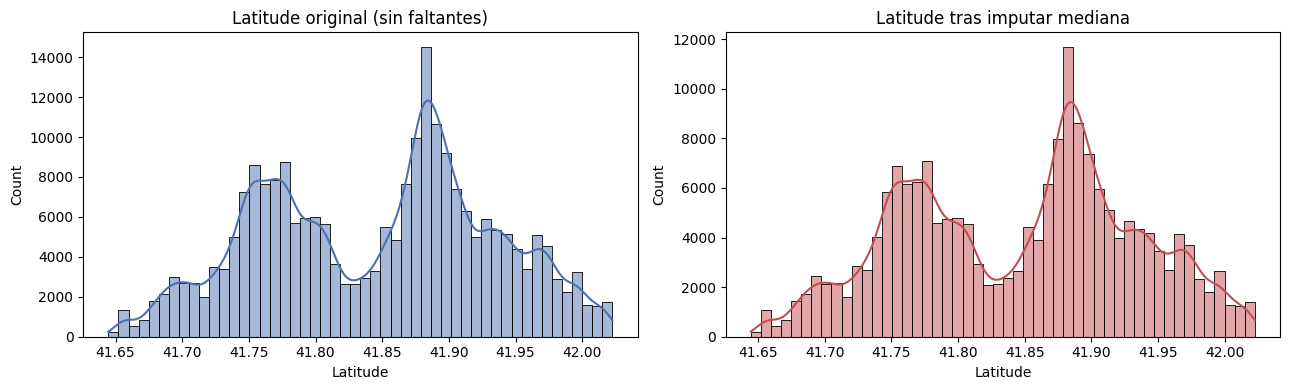

          original     imputada
count  235763.0000  189729.0000
mean       41.8460      41.8460
std         0.0864       0.0864
min        41.6446      41.6446
25%        41.7717      41.7717
50%        41.8637      41.8637
75%        41.9085      41.9085
max        42.0226      42.0226


In [35]:
original = df["Latitude"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(original, bins=50, ax=axes[0], color="#4C72B0", kde=True)
axes[0].set_title("Latitude original (sin faltantes)")
sns.histplot(X_train["Latitude"], bins=50, ax=axes[1], color="#C44E52", kde=True)
axes[1].set_title("Latitude tras imputar mediana")
plt.tight_layout(); plt.show()

print(pd.DataFrame({"original": original.describe(),
                    "imputada": X_train["Latitude"].describe()}).round(4))

## 6. Feature engineering: codificación, escalado y balance de clases

### 6.1 Codificación de variables categóricas

Codificamos cada variable según su tipo:
- **Categóricas** (`Primary Type`, `Description`, `Location Description`, `Beat`,
  `District`, `Ward`, `Community Area`, `Month`) → **Target Encoding**: reemplazamos cada
  categoría por su **tasa media de arresto**.
- **Cíclica** (`Hour`) → **seno/coseno**.
- **Booleanas** (`Domestic`, `IsWeekend`) y el target `Arrest` → **0/1**.

In [36]:
# Target y booleanas a entero 0/1
y_train, y_test = y_train.astype(int), y_test.astype(int)
for col in ["Domestic", "IsWeekend"]:
    X_train[col] = X_train[col].astype(int)
    X_test[col] = X_test[col].astype(int)

target_enc_cols = ["Primary Type", "Description", "Location Description", "Beat",
               "District", "Ward", "Community Area", "Month"]
# convertir categóricas a str para el encoder
for c in target_enc_cols:
    X_train[c] = X_train[c].astype(str)
    X_test[c] = X_test[c].astype(str)

te = TargetEncoder(cols=target_enc_cols, smoothing=10)
X_train_enc = te.fit_transform(X_train, y_train)
X_test_enc = te.transform(X_test)

# Codificación cíclica de la hora
for d in (X_train_enc, X_test_enc):
    d["HourSin"] = np.sin(2 * np.pi * d["Hour"] / 24)
    d["HourCos"] = np.cos(2 * np.pi * d["Hour"] / 24)
X_train_enc = X_train_enc.drop(columns="Hour")
X_test_enc = X_test_enc.drop(columns="Hour")

print("Features tras codificación:", X_train_enc.shape[1])
X_train_enc.head(3)

Features tras codificación: 14


,Primary Type,Description,Location Description,Domestic,Beat,District,Ward,Community Area,Latitude,Longitude,Month,IsWeekend,HourSin,HourCos
200827,0.089793,0.026072,0.256831,0,0.246439,0.303577,0.292261,0.297350,41.866185,-87.724361,0.177162,0,0.965926,0.258819
105450,0.043218,0.063325,0.175051,1,0.124760,0.142199,0.157733,0.132029,41.744339,-87.643858,0.156432,0,0.965926,0.258819
168070,0.089793,0.015225,0.271087,0,0.174387,0.154305,0.191547,0.196825,41.784057,-87.683773,0.164001,0,0.000000,1.000000


### 6.2 Escalado / estandarización

Estandarizamos (**Z-score**, `StandardScaler`) ajustando en train.

In [37]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_enc),
                              columns=X_train_enc.columns, index=X_train_enc.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_enc),
                             columns=X_test_enc.columns, index=X_test_enc.index)
X_train_scaled.describe().round(3).loc[["mean", "std", "min", "max"]]

,Primary Type,Description,Location Description,Domestic,Beat,District,Ward,Community Area,Latitude,Longitude,Month,IsWeekend,HourSin,HourCos
mean,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.717,-0.689,-1.936,-0.485,-1.741,-1.280,-2.343,-1.898,-2.329,-4.454,-1.182,-0.633,-1.256,-1.299
max,4.078,3.575,5.248,2.062,4.292,2.881,3.082,2.768,2.043,2.415,2.204,1.581,1.761,1.449


### 6.3 Análisis y tratamiento del desbalance de clases

El target está desbalanceado (~16 % positivos). Aplicamos **SMOTE** (*oversampling* sintético)
**solo sobre el train**: lo preferimos al *undersampling* porque equilibra **sin tirar datos**
(genera ejemplos sintéticos de la clase minoritaria).

Train antes de SMOTE:   {0: 159353, 1: 30376}
Train después de SMOTE: {0: 159353, 1: 159353}


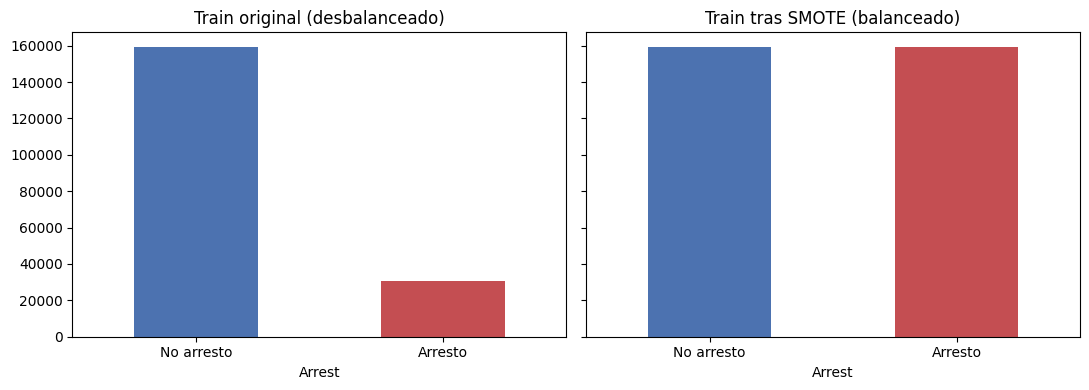

In [38]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f"Train antes de SMOTE:   {dict(y_train.value_counts())}")
print(f"Train después de SMOTE: {dict(pd.Series(y_train_bal).value_counts())}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
y_train.value_counts().sort_index().plot.bar(ax=axes[0], color=["#4C72B0", "#C44E52"])
axes[0].set_title("Train original (desbalanceado)")
axes[0].set_xticklabels(["No arresto", "Arresto"], rotation=0)
pd.Series(y_train_bal).value_counts().sort_index().plot.bar(ax=axes[1], color=["#4C72B0", "#C44E52"])
axes[1].set_title("Train tras SMOTE (balanceado)")
axes[1].set_xticklabels(["No arresto", "Arresto"], rotation=0)
plt.tight_layout(); plt.show()

## 7. Reducción de dimensionalidad

### 7.1 Selección de features por filtros

Aplicamos los **filtros que vimos en clase**, calculados sobre el train **antes** de
balancear (así no medimos la relevancia sobre los datos sintéticos de SMOTE):

1. **Filtro de varianza** (`VarianceThreshold`)
2. **ANOVA F** (`f_classif`)
3. **Chi²** (`chi2`)
4. **Información mutua** (`mutual_info_classif`)

In [39]:
# 1. Filtro de varianza (sobre las features SIN escalar)
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_train_enc)
near_constant = X_train_enc.columns[~vt.get_support()].tolist()
print("Features con varianza ~0 (descartables):", near_constant or "ninguna")

Features con varianza ~0 (descartables): ninguna


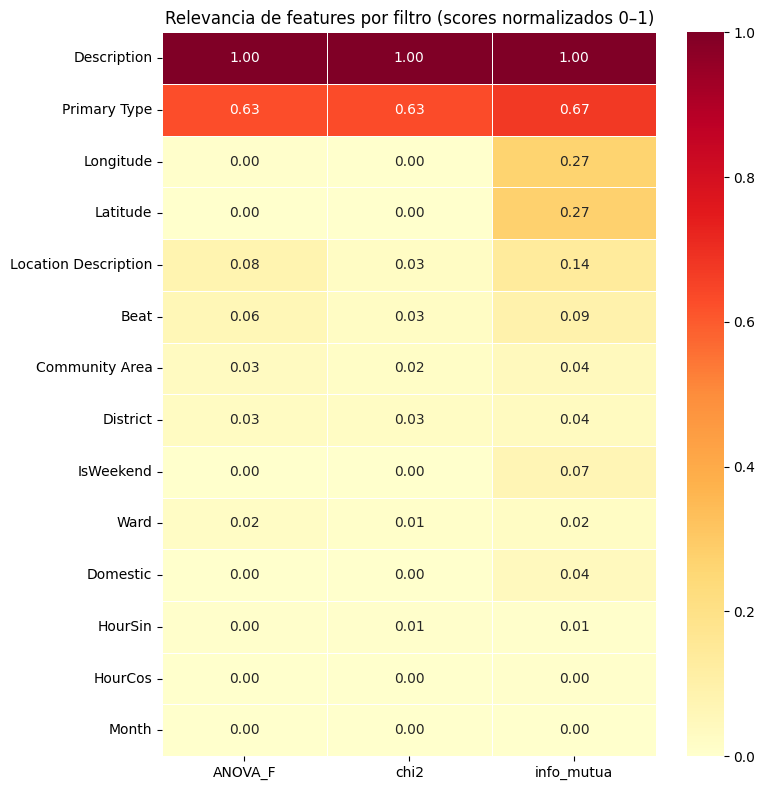

,ANOVA_F,chi2,info_mutua,promedio
Description,1.000,1.000,1.000,1.000
Primary Type,0.625,0.629,0.673,0.643
Longitude,0.004,0.001,0.269,0.091
Latitude,0.000,0.000,0.274,0.091
Location Description,0.079,0.026,0.137,0.081
Beat,0.061,0.027,0.091,0.060
Community Area,0.035,0.019,0.045,0.033
District,0.028,0.025,0.035,0.030
IsWeekend,0.000,0.000,0.067,0.022
Ward,0.021,0.008,0.024,0.017


In [40]:
# 2-4. Tres filtros, todos sobre el train PRE-SMOTE
scores = pd.DataFrame(index=X_train_enc.columns)

f_sel = SelectKBest(score_func=f_classif, k="all").fit(X_train_scaled, y_train)
scores["ANOVA_F"] = f_sel.scores_

# chi2 necesita valores no negativos -> escalamos a [0,1] solo para este filtro
X_train_mm = MinMaxScaler().fit_transform(X_train_enc)
chi_sel = SelectKBest(score_func=chi2, k="all").fit(X_train_mm, y_train)
scores["chi2"] = chi_sel.scores_

mi_sel = SelectKBest(score_func=mutual_info_classif, k="all").fit(X_train_scaled, y_train)
scores["info_mutua"] = mi_sel.scores_

scores_norm = pd.DataFrame(MinMaxScaler().fit_transform(scores),
                           columns=scores.columns, index=scores.index)
scores_norm["promedio"] = scores_norm.mean(axis=1)
scores_norm = scores_norm.sort_values("promedio", ascending=False)

plt.figure(figsize=(8, 8))
sns.heatmap(scores_norm[["ANOVA_F", "chi2", "info_mutua"]], annot=True, fmt=".2f",
            cmap="YlOrRd", vmin=0, vmax=1, linewidths=0.5)
plt.title("Relevancia de features por filtro (scores normalizados 0–1)")
plt.tight_layout(); plt.show()
scores_norm.round(3)

Nos quedamos con las features cuyo score promedio (entre los tres filtros) pasa un umbral.

In [41]:
THRESHOLD = 0.05
selected_features = scores_norm[scores_norm["promedio"] >= THRESHOLD].index.tolist()
dropped_features = scores_norm[scores_norm["promedio"] < THRESHOLD].index.tolist()
print(f"Features seleccionadas ({len(selected_features)}): {selected_features}")
print(f"\nFeatures descartadas ({len(dropped_features)}): {dropped_features}")

X_train_sel = X_train_bal[selected_features]
X_test_sel = X_test_scaled[selected_features]
print("\nShape train tras selección:", X_train_sel.shape)

Features seleccionadas (6): ['Description', 'Primary Type', 'Longitude', 'Latitude', 'Location Description', 'Beat']

Features descartadas (8): ['Community Area', 'District', 'IsWeekend', 'Ward', 'Domestic', 'HourSin', 'HourCos', 'Month']

Shape train tras selección: (318706, 6)


> Observamos que `Description` y `Primary Type` dominan.
> Las **coordenadas** son un caso interesante: dan ~0 en ANOVA F y chi² pero **alto en
> información mutua** → su relación con el arresto es **no lineal**. `Location Description` y
> `Beat` pasan más ajustadas, y el resto (temporales y `Domestic`) queda en ~0 → así nos
> quedan **6 features**. `Description` lidera porque el **subtipo** mueve mucho la tasa de
> arresto dentro de cada `Primary Type` (`RETAIL THEFT` vs. otros hurtos).

### 7.2 Extracción de features con PCA

Corremos **PCA** sobre las features estandarizadas para ver cuánta varianza podemos capturar
con menos componentes.

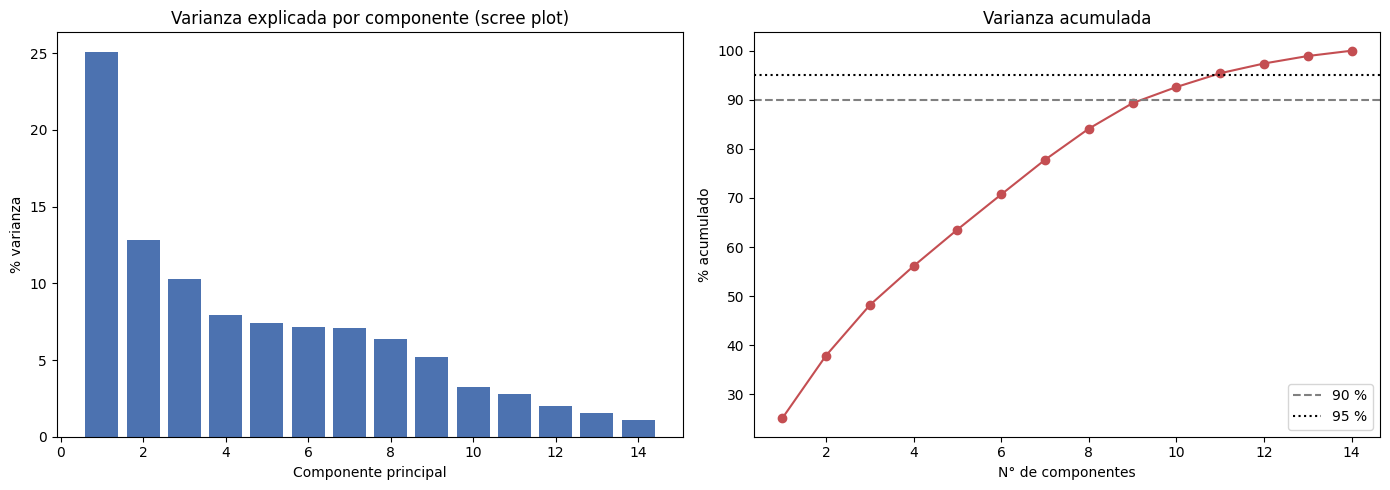

Componentes para 90% de varianza: 10 de 14
Componentes para 95% de varianza: 11 de 14
Componentes para 99% de varianza: 14 de 14


In [42]:
pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_train_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(explained_var) + 1), explained_var * 100, color="#4C72B0")
axes[0].set_title("Varianza explicada por componente (scree plot)")
axes[0].set_xlabel("Componente principal"); axes[0].set_ylabel("% varianza")

axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var * 100, marker="o", color="#C44E52")
axes[1].axhline(90, color="gray", ls="--", label="90 %")
axes[1].axhline(95, color="black", ls=":", label="95 %")
axes[1].set_title("Varianza acumulada")
axes[1].set_xlabel("N° de componentes"); axes[1].set_ylabel("% acumulado"); axes[1].legend()
plt.tight_layout(); plt.show()

for threshold in (0.90, 0.95, 0.99):
    n = int(np.argmax(cumulative_var >= threshold) + 1)
    print(f"Componentes para {threshold*100:.0f}% de varianza: {n} de {X_train_scaled.shape[1]}")

Miramos los **loadings** (cuánto aporta cada variable original a las primeras componentes) y
la **contribución porcentual** por componente, para entender qué representa cada eje.

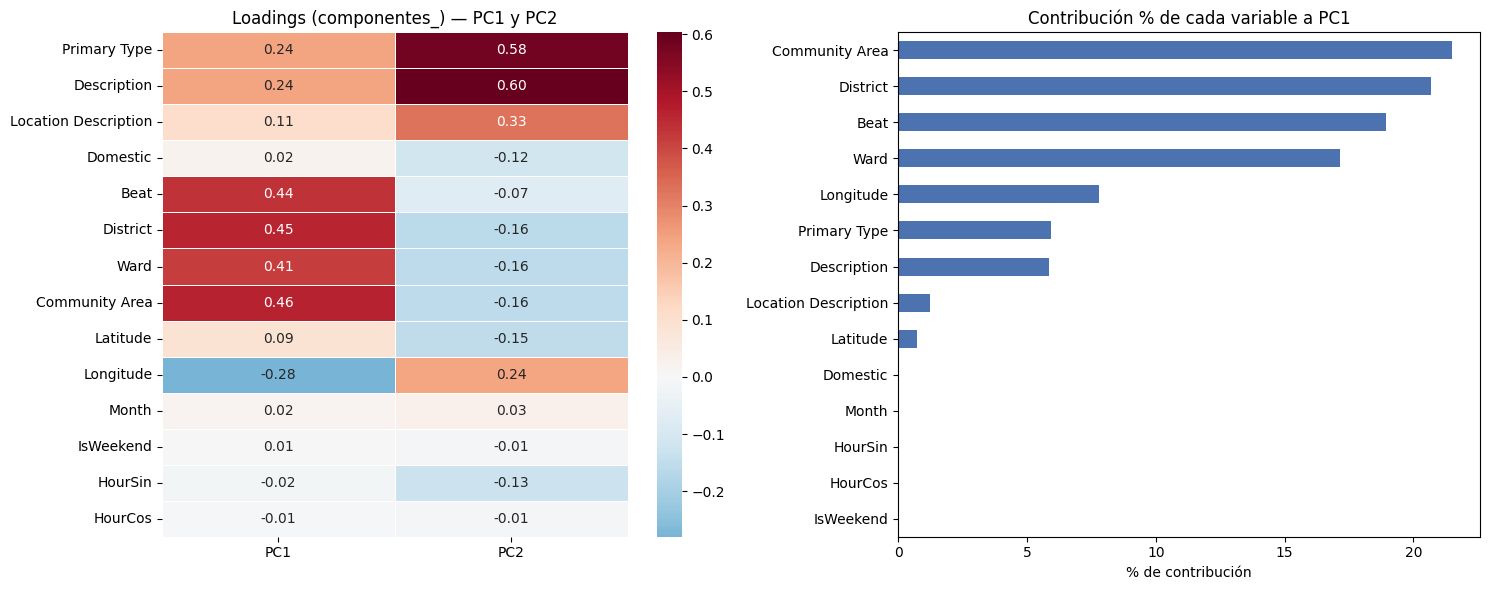

In [43]:
loadings = pd.DataFrame(pca.components_[:2].T, columns=["PC1", "PC2"],
                        index=X_train_scaled.columns)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=axes[0])
axes[0].set_title("Loadings (componentes_) — PC1 y PC2")

# Contribución porcentual = loading^2 normalizado por componente
contrib = (loadings ** 2)
contrib = contrib / contrib.sum() * 100
contrib["PC1"].sort_values().plot.barh(ax=axes[1], color="#4C72B0")
axes[1].set_title("Contribución % de cada variable a PC1")
axes[1].set_xlabel("% de contribución")
plt.tight_layout(); plt.show()

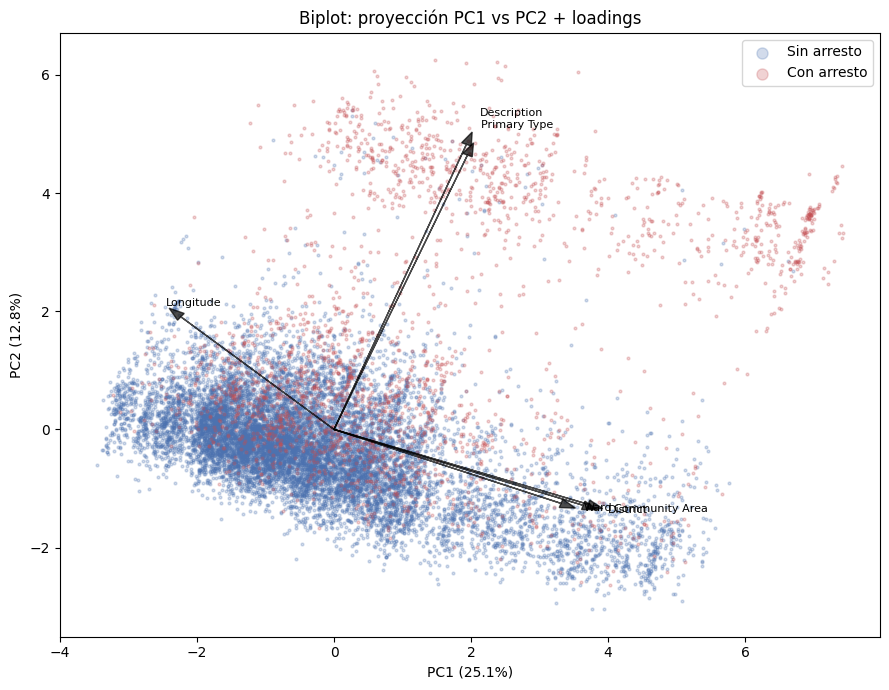

In [44]:
# Proyección (scores) de una muestra sobre PC1-PC2 con biplot (flechas de loadings)
scores_pca = pca.transform(X_train_scaled)[:, :2]
idx = np.random.choice(len(scores_pca), 15000, replace=False)

plt.figure(figsize=(9, 7))
for val, color, label in [(0, "#4C72B0", "Sin arresto"), (1, "#C44E52", "Con arresto")]:
    m = y_train.values[idx] == val
    plt.scatter(scores_pca[idx][m, 0], scores_pca[idx][m, 1], s=4, alpha=0.25, c=color, label=label)

# Flechas de loadings (top 6 por magnitud en PC1/PC2) -> biplot
arrow_scale = 8
top_vars = loadings.abs().sum(axis=1).sort_values(ascending=False).head(6).index
for var in top_vars:
    plt.arrow(0, 0, loadings.loc[var, "PC1"] * arrow_scale, loadings.loc[var, "PC2"] * arrow_scale,
              color="black", alpha=0.7, head_width=0.15)
    plt.text(loadings.loc[var, "PC1"] * arrow_scale * 1.1, loadings.loc[var, "PC2"] * arrow_scale * 1.1,
             var, fontsize=8)
plt.title("Biplot: proyección PC1 vs PC2 + loadings")
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}%)"); plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}%)")
plt.legend(markerscale=4); plt.tight_layout(); plt.show()

In [45]:
# Aplicamos el PCA entrenado (en train) también al test -> sin data leakage
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("Shape PCA train:", X_train_pca.shape, "| test:", X_test_pca.shape)
n90 = int(np.argmax(cumulative_var >= 0.90) + 1)
print(f"Conservando {n90} componentes (90% var.): train {X_train_pca[:, :n90].shape}, "
      f"test {X_test_pca[:, :n90].shape}")

Shape PCA train: (189729, 14) | test: (47434, 14)
Conservando 10 componentes (90% var.): train (189729, 10), test (47434, 10)


**¿Conviene usar PCA acá?** En general PCA baja la dimensionalidad y descorrelaciona las
features, pero acá casi no hay nada que ganar: **comprime muy poco** (hacen falta **10 de 14
componentes** para el 90 % de la varianza, porque las features target-encoded ya están poco
correlacionadas) y **perdemos interpretabilidad** (las componentes son combinaciones lineales
sin un significado claro), justo cuando nuestras variables más predictivas (`Description`,
`Primary Type`) ya quedaron comprimidas en pocas columnas por el target encoding.

**Qué decidimos:** nos quedamos con las features que elegimos por los filtros (que son
interpretables) y dejamos PCA como alternativa documentada, no como un paso obligatorio.

## 8. Conclusiones

Preparamos el dataset de crímenes de Chicago 2025 para una **clasificación binaria de `Arrest`**
(desbalanceado, ~16 %). Lo que más predice el arresto es el **tipo de delito** —`Primary Type` y
sobre todo el subtipo `Description`—, confirmado con Cramér's V e información mutua.

Todo el preprocesamiento se hizo **sin fuga de información**: primero el split estratificado, y
recién después la imputación (geo **MAR** → mediana por `Beat`), la codificación (target encoding
y cíclica), la estandarización, el balanceo con **SMOTE solo en train** y la selección de features
por filtros (PCA queda documentado como alternativa).

### Lo que dejamos listo para entrenar
- `X_train_sel`, `y_train_bal`: train con las features seleccionadas, escalado y balanceado.
- `X_test_sel`, `y_test`: test con las mismas features, escalado y **sin balancear** (para
  evaluar con la realidad).